In [17]:
# imports
import pandas as pd
import numpy as np
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [18]:
# import data
df = pd.read_csv('qb_data.csv')
df.columns

Index(['player_display_name', 'season', 'aggressiveness', 'pass_yards',
       'completions', 'interceptions', 'pass_touchdowns', 'touchdowns_next',
       'twenty_next'],
      dtype='object')

In [19]:
# define what we are predicting (y) and what we are using to predict it (X)
X = df[['aggressiveness', 'pass_yards', 'completions', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']

X = sm.add_constant(X)  
X = X.astype(float)

# get VIF
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

           feature        VIF
0            const  39.943520
1   aggressiveness   1.090303
2       pass_yards  24.496126
3      completions  17.913906
4    interceptions   1.484519
5  pass_touchdowns   4.323311


In [ ]:
# Why should we remove aggressiveness? (look at p values in model output)
X = df[['aggressiveness','pass_yards', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']
X = X.astype(float)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        touchdowns_next   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     16.94
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           2.46e-12
Time:                        14:17:57   Log-Likelihood:                -926.76
No. Observations:                 261   AIC:                             1864.
Df Residuals:                     256   BIC:                             1881.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              13.1258      3.247     

In [21]:
X = df[['pass_yards', 'interceptions', 'pass_touchdowns']]

y = df['touchdowns_next']
X = X.astype(float)

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
#print(model.summary())

predictions = model.predict(X)

mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)

print(f'RMSE: {rmse}')

RMSE: 8.430784893526027


In [22]:



predictions = model.predict(X)

mse = mean_squared_error(y, predictions)
rmse = np.sqrt(mse)

print(f'RMSE: {rmse}')

RMSE: 8.430784893526027


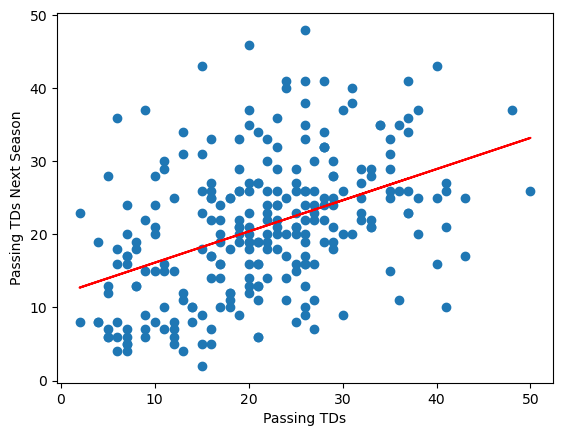

In [23]:
X = df[['pass_touchdowns']]
y = df['touchdowns_next']

m, b = np.polyfit(df['pass_touchdowns'], df['touchdowns_next'], 1)

plt.scatter(X,y)
plt.xlabel('Passing TDs')
plt.ylabel('Passing TDs Next Season')
plt.plot(X, m*X + b, color='red') 

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

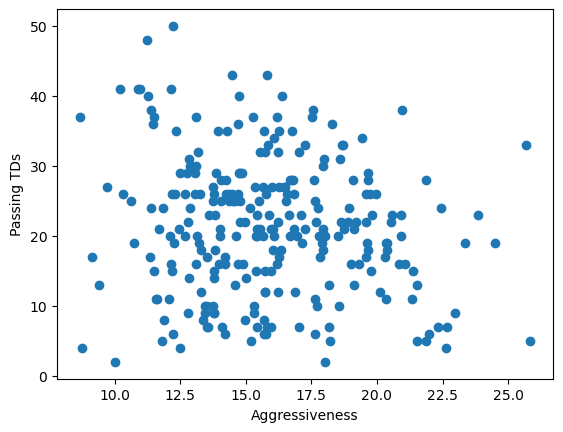

In [24]:
X = df[['aggressiveness']]
y = df['pass_touchdowns']

plt.xlabel('Aggressiveness')
plt.ylabel('Passing TDs')
plt.scatter(X,y)
plt.show

In [25]:
# How to use model output
# Sam Darnold 2025 stats: 4048 pass yds, 14 ints, 25 pass tds (always add the constant)
print("predicted 2026 pass TDs:", (12.7294 + (4048 * 0.0014) + (25 * 0.3444) + (14 * -0.3743)))

# Bryce Young 2025 stats: 3011 pass yds, 11 ints, 23 pass tds
# How many TDs is Bryce Young predicted to throw in 2026?

predicted 2026 pass TDs: 21.766399999999997


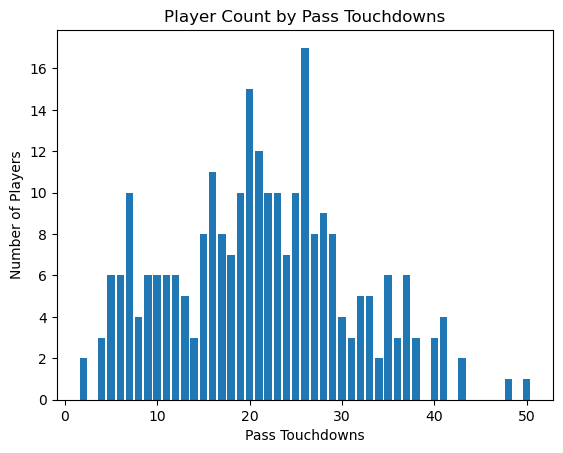

In [ ]:
# why do the predictions seem low?
td_counts = df['pass_touchdowns'].value_counts().sort_index()

plt.bar(td_counts.index, td_counts.values)
plt.xlabel('Pass Touchdowns')
plt.ylabel('Number of Players')
plt.title('Player Count by Pass Touchdowns')
plt.show()